In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [3]:
df_us = df[df["job_country"] == 'United States'].copy()

In [4]:
#to get month names from job_posted_date into a new column job_posted_month by using dt str format time (%B)
df_us["job_posted_month"] = df_us["job_posted_date"].dt.strftime("%B")
df_us

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,None,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,None,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,None,NaN,NaN,JPMorgan Chase & Co.,None,None,October
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,None,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",July
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}",April
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None,January


In [5]:
df_us['job_posted_month'] = df_us['job_posted_date'].dt.to_period('M')
df_us

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,2023-06
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",2023-07
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",2023-11
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,None,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",2023-03
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,None,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",2023-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,None,NaN,NaN,JPMorgan Chase & Co.,None,None,2023-10
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,None,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",2023-07
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}",2023-04
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None,2023-01


In [6]:
df_us = df_us.set_index('job_posted_month')


In [7]:
df_us.sort_index(ascending = True, inplace = True)
df_us

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_posted_month,,,,,,,,,,,,,,,,,
2023-01,Data Analyst,Junior Data Analyst,"Baltimore, MD",via LinkedIn,Full-time,False,"New York, United States",2023-01-07 06:00:33,False,False,United States,None,NaN,NaN,Staffigo,"['oracle', 'excel', 'power bi', 'tableau']","{'analyst_tools': ['excel', 'power bi', 'table..."
2023-01,Data Scientist,Data Science Manager,"Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-11 06:20:33,False,True,United States,year,234500.0,NaN,TikTok,"['python', 'sql', 'r', 'neo4j', 'pandas', 'spa...","{'analyst_tools': ['tableau'], 'databases': ['..."
2023-01,Data Analyst,Junior Data Analyst,"Columbia, MD",via LinkedIn,Full-time,False,"New York, United States",2023-01-07 06:00:33,False,False,United States,None,NaN,NaN,Staffigo,"['oracle', 'excel', 'power bi', 'tableau']","{'analyst_tools': ['excel', 'power bi', 'table..."
2023-01,Data Scientist,"Data Scientist, Ecosystem Analytics","San Francisco, CA",via Trabajo.org,Full-time,False,"California, United States",2023-01-17 06:20:27,False,True,United States,None,NaN,NaN,Block,"['sql', 'python', 'c', 'go', 'looker', 'flow']","{'analyst_tools': ['looker'], 'other': ['flow'..."
2023-01,Data Analyst,Junior Data Analyst,"Annapolis, MD",via LinkedIn,Full-time,False,"New York, United States",2023-01-07 06:00:32,False,False,United States,None,NaN,NaN,Staffigo,"['oracle', 'excel', 'power bi', 'tableau']","{'analyst_tools': ['excel', 'power bi', 'table..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12,Data Analyst,Data Analytics and IT Service Solution Sales L...,"Chicago, IL",via LinkedIn,Full-time,False,"Illinois, United States",2023-12-26 16:01:09,True,False,United States,None,NaN,NaN,ScaleneWorks INC,None,None
2023-12,Data Scientist,Data Scientist with Security Clearance,United States,via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-12-14 06:04:56,False,False,United States,None,NaN,NaN,SAIC,"['sql', 't-sql', 'python', 'java', 'c#', 'r', ...","{'analyst_tools': ['tableau'], 'libraries': ['..."
2023-12,Data Scientist,Lead Data Scientist. Job in Mettawa FOX8 Jobs,"Mettawa, IL",via FOX8 Jobs,Full-time,False,"Illinois, United States",2023-12-01 12:02:49,False,True,United States,None,NaN,NaN,Cognizant Technology Solutions,"['python', 'r', 'pandas', 'numpy', 'scikit-lea...","{'libraries': ['pandas', 'numpy', 'scikit-lear..."


In [8]:
df_us.index

PeriodIndex(['2023-01', '2023-01', '2023-01', '2023-01', '2023-01', '2023-01',
             '2023-01', '2023-01', '2023-01', '2023-01',
             ...
             '2023-12', '2023-12', '2023-12', '2023-12', '2023-12', '2023-12',
             '2023-12', '2023-12', '2023-12', '2023-12'],
            dtype='period[M]', name='job_posted_month', length=206292)

In [9]:
df_us_pivot = df_us.pivot_table(
    index= df_us.index,
    columns = 'job_title_short',
    aggfunc = 'size',
)

In [10]:
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
2023-01,527,36,8494,2655,6915,60,1544,773,1552,114
2023-02,447,24,6124,3060,4956,56,1258,878,1127,90
2023-03,438,19,6218,3183,4779,59,1114,829,1150,115
2023-04,565,40,6049,2801,4867,51,1025,781,991,112
2023-05,279,20,4993,2976,4377,49,839,746,914,90
2023-06,446,32,5683,2893,4645,48,1009,812,1033,93
2023-07,581,39,5201,2570,4876,65,883,747,1095,153
2023-08,903,39,6634,3269,6318,68,1186,903,1515,194
2023-09,897,50,4639,3224,4568,113,805,775,1014,228


In [ ]:
#Not only get the top 3 job title (short) And take the index which is the job titles and put into a list
top_3 = df["job_title_short"].value_counts().head(3)
top_3 = top_3.index.tolist()
top_3

['Data Analyst', 'Data Engineer', 'Data Scientist']

Text(0, 0.5, 'No. of jobs')

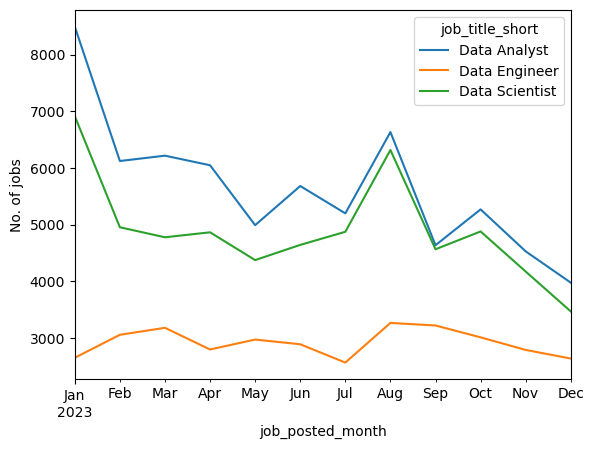

In [15]:
df_us_pivot[top_3].plot(kind = 'line')
plt.ylabel("No. of jobs")